# KOTE Exploratory Data Analysis

## Objectives
- Inspect the structure of the KOTE dataset
- Analyze emotion label distribution
- Analyze sentence length
- Analyze the number of emotion labels per sentence
- Identify basic characteristics of the multi-label classification task

In [2]:
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
test = 123


In [3]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"

FIGURE_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"

SRC_DIR = PROJECT_ROOT / "src"

print("Project root:", PROJECT_ROOT)
print("Raw data:", DATA_DIR)
print("Source directory:", SRC_DIR)

Project root: /home/bean/Programming/26_09_SelfProject/Self-Project
Raw data: /home/bean/Programming/26_09_SelfProject/Self-Project/data/raw
Source directory: /home/bean/Programming/26_09_SelfProject/Self-Project/src


In [4]:
import sys

sys.path.append(str(SRC_DIR))

from utils.labels import LABELS

print("Number of labels:", len(LABELS))

Number of labels: 44


In [5]:
for file in DATA_DIR.iterdir():
    print(file.name)

val.tsv
train.tsv
test.tsv


In [6]:
train_path = DATA_DIR / "train.tsv"
val_path = DATA_DIR / "val.tsv"
test_path = DATA_DIR / "test.tsv"

train_df = pd.read_csv(train_path, sep="\t", header=None, names=["id", "text", "labels"])
val_df = pd.read_csv(val_path, sep="\t", header=None, names=["id", "text", "labels"])
test_df = pd.read_csv(test_path, sep="\t", header=None, names=["id", "text", "labels"])

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (40000, 3)
Validation: (5000, 3)
Test: (5000, 3)


,id,text,labels
0,39087,내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.,"2,13,15,16,29,39"
1,30893,"정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...","0,5,7,10,19,22,29,35,36,38"
2,45278,"새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...","1,2,7"
3,16398,미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,"9,15,20,23,26,28,29"
4,13653,네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ,"1,2,8,9,11,13,15,16,28,29,32,40,42"


In [7]:
print(train_df.columns.tolist())
print()

train_df.info()
train_df.head(3)

['id', 'text', 'labels']

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      40000 non-null  int64
 1   text    40000 non-null  str  
 2   labels  40000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 937.6 KB


,id,text,labels
0,39087,내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.,"2,13,15,16,29,39"
1,30893,"정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...","0,5,7,10,19,22,29,35,36,38"
2,45278,"새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...","1,2,7"


In [8]:
assert len(train_df) == 40000
assert len(val_df) == 5000
assert len(test_df) == 5000

assert list(train_df.columns) == ["id", "text", "labels"]
assert list(val_df.columns) == ["id", "text", "labels"]
assert list(test_df.columns) == ["id", "text", "labels"]

print("Basic dataset checks passed")

Basic dataset checks passed


## 1. Basic Data Quality Check

In [9]:
print("Train missing values:")
print(train_df.isnull().sum())

print("\nValidation missing values:")
print(val_df.isnull().sum())

print("\nTest missing values:")
print(test_df.isnull().sum())

print("Train duplicated rows:", train_df.duplicated().sum())
print("Validation duplicated rows:", val_df.duplicated().sum())
print("Test duplicated rows:", test_df.duplicated().sum())

Train missing values:
id        0
text      0
labels    0
dtype: int64

Validation missing values:
id        0
text      0
labels    0
dtype: int64

Test missing values:
id        0
text      0
labels    0
dtype: int64
Train duplicated rows: 0
Validation duplicated rows: 0
Test duplicated rows: 0


## 2. Emotion Label Distribution

In [10]:
label_counter = Counter()

for labels in train_df["labels"]:
    label_ids = [int(x) for x in labels.split(",")]
    label_counter.update(label_ids)

label_counts = pd.Series(label_counter).sort_index()

label_counts

0     16696
1      9252
2     10778
3      6386
4      5181
5      4137
6     12299
7      3854
8     11197
9      6002
10    17465
11     3352
12    11565
13     5229
14     3771
15    10638
16     7173
17     2329
18     1194
19     3652
20    12201
21     3864
22    14930
23    15996
24     6344
25     1581
26     2428
27     3769
28    10867
29     8151
30      698
31     7684
32     4401
33     9996
34     5193
35     4768
36     2031
37     3691
38     5451
39     7355
40     7473
41     7541
42     9967
43     7929
dtype: int64

In [11]:
print("Number of unique label IDs:", len(label_counts))
print("Minimum label ID:", label_counts.index.min())
print("Maximum label Id:", label_counts.index.max())

Number of unique label IDs: 44
Minimum label ID: 0
Maximum label Id: 43


In [12]:
label_distribution_df = pd.DataFrame({
    "label_id": label_counts.index,
    "label_name": [LABELS[i] for i in label_counts.index],
    "count": label_counts.values
})

label_distribution_sorted = label_distribution_df.sort_values(
    by="count",
    ascending=False
).reset_index(drop=True)

label_distribution_sorted

,label_id,label_name,count
0,10,안타까움/실망,17465
1,0,불평/불만,16696
2,23,어이없음,15996
3,22,짜증,14930
4,6,화남/분노,12299
5,20,한심함,12201
6,12,의심/불신,11565
7,8,기대감,11197
8,28,즐거움/신남,10867
9,2,감동/감탄,10778


In [13]:
print("Most frequent labels:")
display(label_distribution_sorted.head(10))

print("Least frequent labels:")
display(label_distribution_sorted.tail(10))

Most frequent labels:


,label_id,label_name,count
0,10,안타까움/실망,17465
1,0,불평/불만,16696
2,23,어이없음,15996
3,22,짜증,14930
4,6,화남/분노,12299
5,20,한심함,12201
6,12,의심/불신,11565
7,8,기대감,11197
8,28,즐거움/신남,10867
9,2,감동/감탄,10778


Least frequent labels:


,label_id,label_name,count
34,27,힘듦/지침,3769
35,37,재미없음,3691
36,19,절망,3652
37,11,비장함,3352
38,26,귀찮음,2428
39,17,부끄러움,2329
40,36,서러움,2031
41,25,패배/자기혐오,1581
42,18,공포/무서움,1194
43,30,죄책감,698


In [14]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "NanumGothic"
mpl.rcParams["axes.unicode_minus"] = False

from matplotlib import font_manager

[f.name for f in font_manager.fontManager.ttflist if "Nanum" in f.name]

['NanumSquareRound',
 'NanumSquareRound Bold',
 'NanumSquare',
 'NanumSquare Bold',
 'NanumSquareRound',
 'NanumSquareRound Regular',
 'NanumBarunGothic',
 'NanumGothic',
 'NanumBarunGothic',
 'NanumMyeongjo',
 'NanumSquare',
 'NanumGothic',
 'NanumGothicCoding',
 'NanumGothicCoding',
 'NanumMyeongjo']

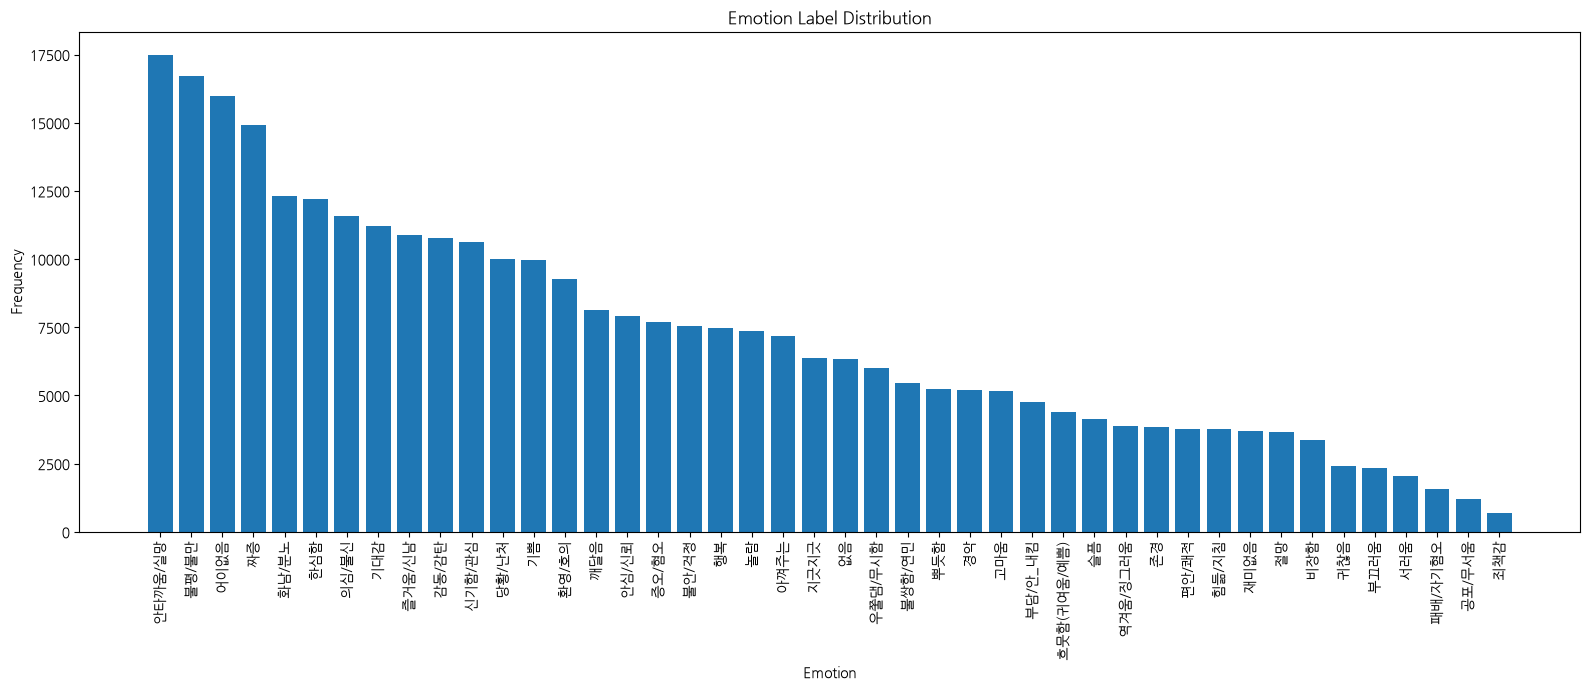

In [16]:
plt.figure(figsize=(16, 7))

plt.bar(
    label_distribution_sorted["label_name"],
    label_distribution_sorted["count"]
)

plt.title("Emotion Label Distribution")
plt.xlabel("Emotion")
plt.ylabel("Frequency")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "label_distribution.png",
    dpi=300
)

plt.show()

In [17]:
label_distribution_sorted.to_csv(
    METRICS_DIR / "label_distribution.csv",
    index=False
)

label_distribution_sorted.head()

,label_id,label_name,count
0,10,안타까움/실망,17465
1,0,불평/불만,16696
2,23,어이없음,15996
3,22,짜증,14930
4,6,화남/분노,12299


## 3. Sentence Length Analysis

In [18]:
train_df["char_length"] = train_df["text"].str.len()
train_df[["text", "char_length"]].head()

,text,char_length
0,내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.,37
1,"정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...",75
2,"새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...",81
3,미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,44
4,네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ,27


In [19]:
print(train_df["char_length"].describe())

print("\nMedian:", train_df["char_length"].median())
print("90th percentile:", train_df["char_length"].quantile(0.90))
print("95th percentile:", train_df["char_length"].quantile(0.95))
print("99th percentile:", train_df["char_length"].quantile(0.99))

count    40000.000000
mean        57.202525
std         44.877412
min         10.000000
25%         28.000000
50%         42.000000
75%         71.000000
max        404.000000
Name: char_length, dtype: float64

Median: 42.0
90th percentile: 115.0
95th percentile: 139.0
99th percentile: 237.0


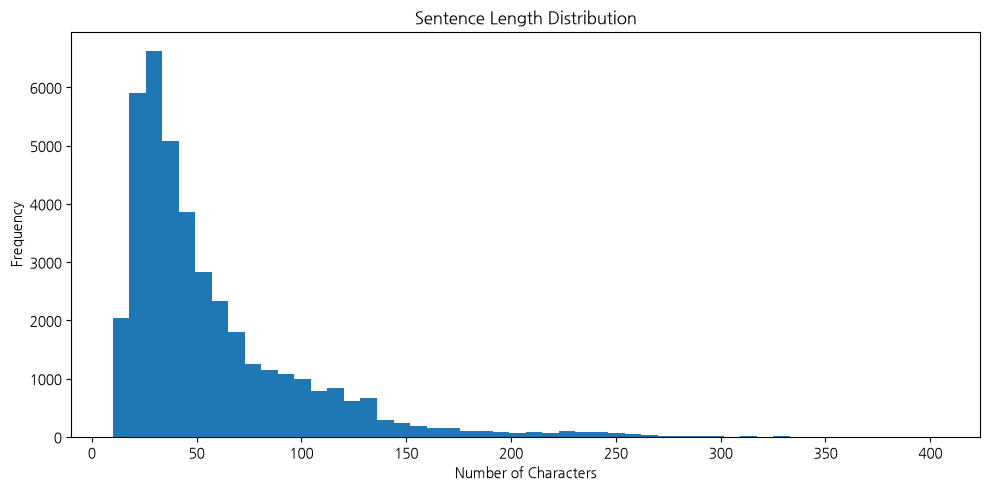

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(train_df["char_length"], bins=50)

plt.title("Sentence Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "sentence_length_distribution.png",
    dpi=300
)

plt.show()

## 4. Number of Labels per Sentence

In [21]:
train_df["num_labels"] = train_df["labels"].apply(
    lambda x: len(x.split(","))
)

train_df[["text", "labels", "num_labels"]].head()

,text,labels,num_labels
0,내가 톰행크스를 좋아하긴 했나보다... 초기 영화 빼고는 다 봤네.,"2,13,15,16,29,39",6
1,"정말 상상을 초월하는 무개념 진상들 상대하다 우울증, 공항장애 걸리는 공무원 많아요...","0,5,7,10,19,22,29,35,36,38",10
2,"새로운 세상과 조우한 자의 어린아이 같은 반응, 어쩌면 회복된 것은 눈이 아닌 순수...","1,2,7",3
3,미역은 원생생물계 산호초는 동물ㅇㅇ 아 미역이 바다의 새ㄱㅇㄱㅋㅋㅋㅋㅋㅋㅋㅋㅋㅋ,"9,15,20,23,26,28,29",7
4,네 맞습니다 플스는 역시 30프레임이 어울리죠 ㅎ,"1,2,8,9,11,13,15,16,28,29,32,40,42",13


In [22]:
print(train_df["num_labels"].describe())

print("\nAverage labels per sentence:", train_df["num_labels"].mean())
print("Maximum labels in one sentence:", train_df["num_labels"].max())

count    40000.000000
mean         7.911475
std          3.098085
min          1.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         22.000000
Name: num_labels, dtype: float64

Average labels per sentence: 7.911475
Maximum labels in one sentence: 22


In [23]:
single_label_count = (train_df["num_labels"] == 1).sum()
multi_label_count = (train_df["num_labels"] > 1).sum()

total_count = len(train_df)

single_label_ratio = single_label_count / total_count
multi_label_ratio = multi_label_count / total_count

print(f"Single-label samples: {single_label_count} ({single_label_ratio:.2%})")
print(f"Multi-label samples: {multi_label_count} ({multi_label_ratio:.2%})")

Single-label samples: 361 (0.90%)
Multi-label samples: 39639 (99.10%)


In [24]:
labels_per_sentence = train_df["num_labels"].value_counts().sort_index()

labels_per_sentence

num_labels
1      361
2      939
3     1641
4     2557
5     3613
6     4456
7     5042
8     4834
9     4537
10    3895
11    3035
12    2151
13    1350
14     819
15     383
16     178
17     113
18      59
19      19
20      12
21       3
22       3
Name: count, dtype: int64

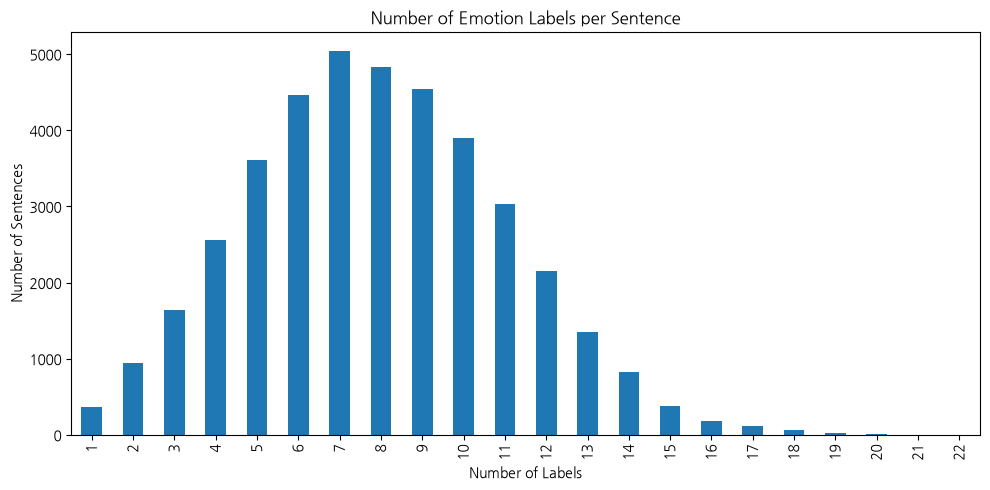

In [25]:
plt.figure(figsize=(10, 5))

labels_per_sentence.plot(kind="bar")

plt.title("Number of Emotion Labels per Sentence")
plt.xlabel("Number of Labels")
plt.ylabel("Number of Sentences")

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "labels_per_sentence.png",
    dpi=300
)

plt.show()

In [27]:
summary_statistics = pd.DataFrame({
    "metric": [
        "train_samples",
        "validation_samples",
        "test_samples",
        "average_sentence_length",
        "median_sentence_length",
        "90th_percentile_sentence_length",
        "95th_percentile_sentence_length",
        "99th_percentile_sentence_length",
        "average_labels_per_sentence",
        "max_labels_per_sentence",
        "single_label_ratio",
        "multi_label_ratio"
    ],
    "value": [
        len(train_df),
        len(val_df),
        len(test_df),
        train_df["char_length"].mean(),
        train_df["char_length"].median(),
        train_df["char_length"].quantile(0.90),
        train_df["char_length"].quantile(0.95),
        train_df["char_length"].quantile(0.99),
        train_df["num_labels"].mean(),
        train_df["num_labels"].max(),
        single_label_ratio,
        multi_label_ratio
    ]
})

summary_statistics.to_csv(
    METRICS_DIR / "eda_summary.csv",
    index=False
)

summary_statistics

,metric,value
0,train_samples,40000.000000
1,validation_samples,5000.000000
2,test_samples,5000.000000
3,average_sentence_length,57.202525
4,median_sentence_length,42.000000
5,90th_percentile_sentence_length,115.000000
6,95th_percentile_sentence_length,139.000000
7,99th_percentile_sentence_length,237.000000
8,average_labels_per_sentence,7.911475
9,max_labels_per_sentence,22.000000
